# Bai thuc hanh so 4 - Phan 2

## Phan tich phan biet tuyen tinh (LDA - Linear Discriminant analysis)
- Trong phần này chúng ta xây dựng chương trình cho phương pháp LDA và ứng dụng trong việc giảm số chiều dữ
liệu. Dữ liệu sau khi được giảm số chiều sẽ được sử dụng cho một số mô hình phân loại đã học (ví dụ Logistic
Regression, SoftMax).
Tương tự PCA, LDA cần khá nhiều tính toán với ma trận, nên chúng ta sẽ sử dụng thư viện Sci-Kit Learn (sklearn)
và/hoặc numpy để tận dụng việc tính toán kiểu vector hóa.

## A. Binary Labeled Data

### Vi du A.1
- . Trong ví dụ này chúng ta tạo 02 tập dữ liệu ngẫu nhiên 02 chiều với số điểm lần lượt là N1 và N2, phân
bố chuẩn với hiệp phương sai và kỳ vọng khác nhau, ứng với 02 nhãn (label) là 1 và 2. Đoạn mã lệnh tương tự với
các bài thực hành trước

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
np.random.seed(12)
means = [[0, 3], [2, 0]]
cov1 = [[1, 0.3], [0.3, 1]] # Nhom X1 co 50 diem tam (0,3) 
cov2 = [[1, 0.2], [0.2, 1.5]] # Nhom x2 co 40 diem tam (2, 0) 
N1 = 50
N2 = 40
N = N1 + N2

X1 = np.random.multivariate_normal(means[0], cov1, N1) # tao ra cac diem du lieu
# tuan theo phan phoi chuan da bien 
X2 = np.random.multivariate_normal(means[1], cov2, N2)
# Combine classes and create labels
# gop du lieuj x, x theo cot , chong 2 ma tran len nhau 
X = np.vstack((X1, X2))
# tao nhan tuong ung, 50 dong dau tien la 1, 40 song tiep theo la 2 
y = np.hstack((np. ones(50), 2*np.ones(40)))

- Đoạn mã dưới đây hiển thị trực quan dữ liệu cũng như đánh dấu tâm điểm (vector trung bình) của mỗi tập dữ liệu
ứng với mỗi nhãn:

Number of samples in Class 1: 50
Number of samples in Class 2: 40
Mean of Class 1: [0.2041277  3.04666639]
Mean of Class 2: [ 1.80478915 -0.18249896]


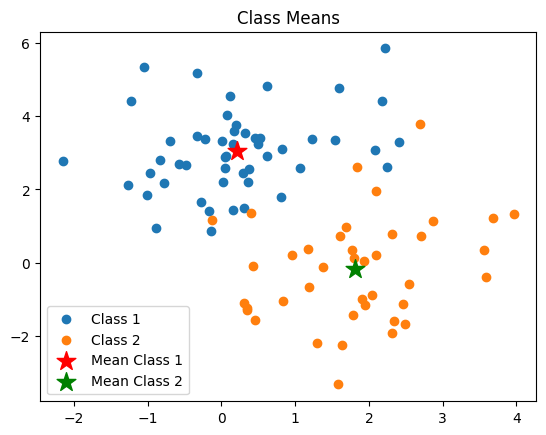

In [ ]:
# Separate data by class to class1 (y=0) and class2 (y=1)
class1 = X[y == 1] # loc ra tat ca cac hang x co nhan = 1
class2 = X[y == 2]
print("Number of samples in Class 1:", class1.shape[0])
print("Number of samples in Class 2:", class2.shape[0])
# Calculate class means
mean1 = np.mean(class1, axis=0) #axis = 0 tinh theo tung cot 
mean2 = np.mean(class2, axis=0)
print("Mean of Class 1:", mean1)
print("Mean of Class 2:", mean2)
# Visualize class means
plt.scatter(class1[:, 0], class1[:, 1], label='Class 1')
plt.scatter(class2[:, 0], class2[:, 1], label='Class 2')
plt.scatter(mean1[0], mean1[1], color='red', s=200, marker='*', label='Mean Class 1')
plt.scatter(mean2[0], mean2[1], color='green', s=200, marker='*', label='Mean Class 2')
plt.legend()
plt.title('Class Means')
plt.show()

- Tiếp theo ta tính Between-Class Variance Matrix SB = (m0 – m1)(m0 – m1)T và Within-Class Variance Matrix
SW = xnX1 (xn – m1)( xn – m1)T + xnX2 (xn – m2)( xn – m2)T

In [8]:
# Build S_B
m1 = np.mean(X1.T, axis = 1, keepdims = True)
m2 = np.mean(X2.T, axis = 1, keepdims = True)
a = (m2 - m1)
S_B = a.dot(a.T)
# Build S_W
SW1 = X1.T - np.tile(m1, (1, N1))
SW2 = X2.T - np.tile(m2, (1, N2))
S_W = SW1.dot(SW1.T) + SW2.dot(SW2.T)
print('Between-class covariance matrix: S_B =\n', S_B)
print('Within-class covariance matrix: S_W =\n',S_W)

Between-class covariance matrix: S_B =
 [[ 2.56211707 -5.16880049]
 [-5.16880049 10.42750887]]
Within-class covariance matrix: S_W =
 [[ 86.83642101  27.51782236]
 [ 27.51782236 140.23997255]]
